In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [27]:
df = pd.read_csv('credit_card_fraud_10k.csv')
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [28]:
df = df.drop(columns=['transaction_id'])
df_encoded = pd.get_dummies(df, columns=['merchant_category'], drop_first=True)

In [29]:
X = df_encoded.drop(columns=['is_fraud'])
y = df_encoded['is_fraud']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [31]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_train_resampled, y_train_resampled)

y_pred_proba = model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.9829


In [32]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

target_recall = 0.90
optimal_idx = np.argmin(np.abs(recalls - target_recall))
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Decision Threshold (for {target_recall*100}% Recall): {optimal_threshold:.4f}")

Optimal Decision Threshold (for 90.0% Recall): 0.1654


In [33]:
y_pred_custom = (y_pred_proba >= optimal_threshold).astype(int)

print("\n--- Classification Report (Tuned Threshold) ---")
print(classification_report(y_test, y_pred_custom))


--- Classification Report (Tuned Threshold) ---
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1970
           1       0.18      0.90      0.31        30

    accuracy                           0.94      2000
   macro avg       0.59      0.92      0.64      2000
weighted avg       0.99      0.94      0.96      2000



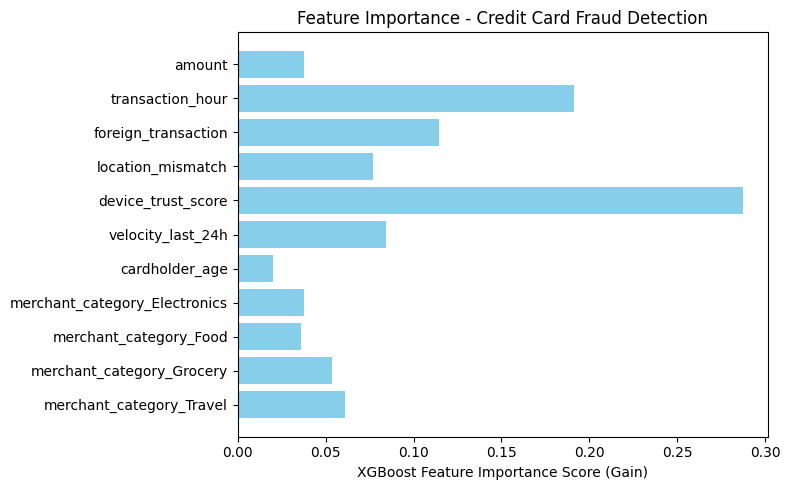

In [34]:
importance = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8, 5))
plt.barh(feature_names, importance, color='skyblue')
plt.xlabel('XGBoost Feature Importance Score (Gain)')
plt.title('Feature Importance - Credit Card Fraud Detection')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()